<a href="https://colab.research.google.com/github/soo423/MachineLearning/blob/main/Chapter02_%EC%82%AC%EC%9D%B4%ED%82%B7%EB%9F%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sklearn
print('사이킷런 버전:', sklearn.__version__)

사이킷런 버전: 1.6.1


In [7]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import pprint

iris = load_iris()
print(iris.keys())
#pprint.pprint(iris)
print('피처 이름:', iris.feature_names)
print('레이블 이름', iris.target_names)
print('피처 데이터 Shape:', iris.data.shape)
print('레이블 shape:', iris.target.shape)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
피처 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
레이블 이름 ['setosa' 'versicolor' 'virginica']
피처 데이터 Shape: (150, 4)
레이블 shape: (150,)


In [8]:
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df ['label'] = iris.target
print('데이터 이름:', iris_df.shape)
iris_df.head(3)

데이터 이름: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [10]:
#학습/테스트 데이터 분리 : 학습셋(80%)과 테스트셋(20%)
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=11)
print('학습셋 크기:', X_train.shape)
print('테스트셋 크기:', X_test.shape)

학습셋 크기: (120, 4)
테스트셋 크기: (30, 4)


In [17]:
#결정 트리(Decision Tree) 모델 생성 및 학습
dt_clf = DecisionTreeClassifier(random_state=11)
dt_clf.fit(X_train, y_train)
print('모델 학습 완료')

모델 학습 완료


In [18]:
#예측 및 성능 평가
pred = dt_clf.predict(X_test)
print('예측값(처음10개):', pred[:10])
print('실제값(처음10개):', y_test[:10])

#정확도 = (맞춘 개수) / (전체 개수)
accuracy = accuracy_score(y_test, pred)
print(f'\n예측 정확도: {accuracy:.4f}')

예측값(처음10개): [2 2 1 1 2 0 1 0 0 1]
실제값(처음10개): [2 2 2 1 2 0 1 0 0 1]

예측 정확도: 0.9333


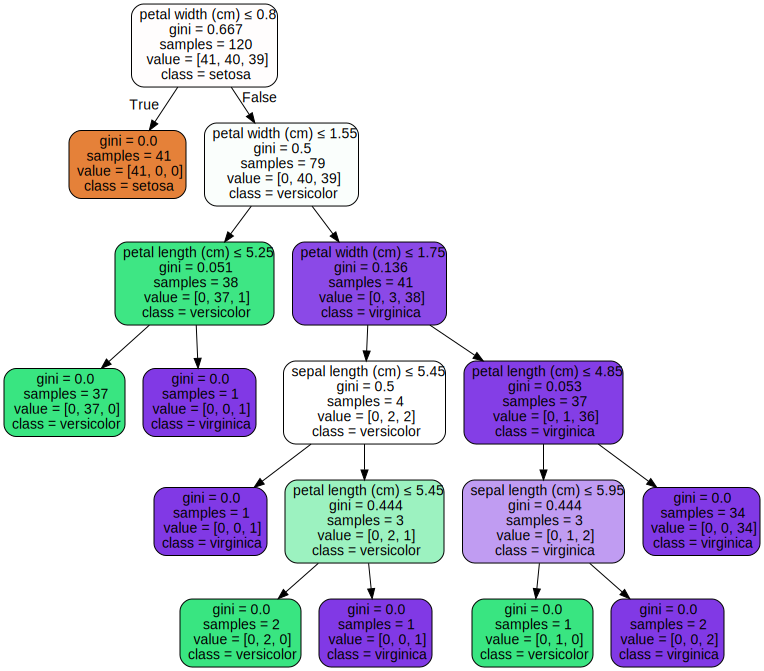

In [19]:
#!pip install graphviz
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(dt_clf, out_file=None, feature_names=iris.feature_names, class_names = iris.target_names,
                           filled=True, rounded=True, special_characters=True)

graph = graphviz.Source(dot_data)
graph

In [22]:
#stratify=y : 클래스 비율을 유지하며 분리 > 한 클래스가 테스트셋에만 몰리는 현상 방지
X, y = iris.data, iris.target
X_tr, X_tes, y_tr, y_tes = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('stratify 적용 후 테스트셋 레이블 분포:')
print(' 0(setosa):', (y_tes==0).sum(),
      '1(versicolor):', (y_tes==1).sum(),
      '2(virgincia):', (y_tes==2).sum())

stratify 적용 후 테스트셋 레이블 분포:
 0(setosa): 10 1(versicolor): 10 2(virgincia): 10


In [30]:
#KFold 교차 검증 - 학습용(train)과 검증용(Validation), 테스트(test) / test.csv tlf
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5)
cv_accuracy = [] #각 폴드별 정확도
n_iter = 0 #반복 횟수

features = iris.data
label    = iris.target

for train_idx, val_idx in kfold.split(iris.data): # 각 분할마다 학습 데이터의 인덱스, 테스트 데이터의 인덱스
  X_tr, X_val = features[train_idx], features[val_idx] #인덱스 배열을 사용하여 원본 데이터에서 학습 세트와 테스트 세트를 분리
  y_tr, y_val = label[train_idx], label[val_idx]

  dt_clf.fit(X_tr, y_tr)
  pred = dt_clf.predict(X_val)
  n_iter += 1
  accuracy = accuracy_score(y_val, pred)

  train_size = X_tr.shape[0]
  test_size = X_val.shape[0]

  print(f'#{n_iter} 교차검증 정확도:{accuracy:.4f} 학습:{train_size} 검증:{test_size}') #각 폴드별 교차 검증
  cv_accuracy.append(accuracy)

print('\n평균 검증 정확도:', np.mean(cv_accuracy).round(4)) #모델의 최종 성능을 평가


#1 교차검증 정확도:1.0000 학습:120 검증:30
#2 교차검증 정확도:0.9667 학습:120 검증:30
#3 교차검증 정확도:0.8667 학습:120 검증:30
#4 교차검증 정확도:0.9333 학습:120 검증:30
#5 교차검증 정확도:0.8333 학습:120 검증:30

평균 검증 정확도: 0.92


In [32]:
#StratifiedKFlod : 계층별 교차 검증
#클래스 비율을 유지하며 폴드 분할 > 불균형 데이터에 필수
from sklearn.model_selection import StratifiedKFold
skfold = StratifiedKFold(n_splits=3)

for train_idx, val_idx in skfold.split(features, label):
  X_tr, X_val = features[train_idx], features[val_idx],
  y_tr, y_val = label[train_idx], label[val_idx]

  dt_clf.fit(X_tr, y_tr)
  pred = dt_clf.predict(X_val)
  n_iter += 1

  accuracy = accuracy_score(y_val, pred)
  print(f'#{n_iter} 교차검증 정확도:{accuracy:.4f} 학습:{train_size} 검증{test_size}') #각 폴드별 교차 검증
  #각 폴드별 레이블 분포 확인
  print(f'검증 레이블 분포 - 0: {(y_val==0).sum()} 1:{(y_val==0).sum()} 2:{(y_val==2).sum()}')
  cv_accuracy.append(accuracy)

print('\n평균 검증 정확도:', np.mean(cv_accuracy).round(4)) #모델의 최종 성능을 평가

#9 교차검증 정확도:0.9800 학습:120 검증30
검증 레이블 분포 - 0: 17 1:17 2:16
#10 교차검증 정확도:0.9200 학습:120 검증30
검증 레이블 분포 - 0: 17 1:17 2:17
#11 교차검증 정확도:0.9800 학습:120 검증30
검증 레이블 분포 - 0: 16 1:16 2:17

평균 검증 정확도: 0.935


In [33]:
#cross_val_score() : 가장 편리한 교차 검증 함수
#KFlod + fit + predict + score를 한 줄로 처리
from sklearn.model_selection import cross_val_score, cross_val_score

scores = cross_val_score(estimator=dt_clf, X=iris.data, y=iris.target, scoring='accuracy', cv=3)#cv: 폴드 수(StratifiedKFold 자동 적용)
print('교차 검증별 정확도:', np.round(scores, 4))
print('평균 검증 정확도:', np.round(scores.mean(), 4))

교차 검증별 정확도: [0.98 0.92 0.98]
평균 검증 정확도: 0.96


In [37]:
#GridSearchCV: 교차검증(Cross Validation) + 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

#학습/테스트셋 분리(GridSearchCV는 학습 데이터만을 사용)
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=121
)
dtree = DecisionTreeClassifier()
params = {'max_depth' : [1,2,3], 'min_samples_split': [2,3]} #탐색할 때 파라미터 범위 지정, 트리의 최대 깊이, 노드를 분할하기 위한 최소 샘플 수
grid_dtree = GridSearchCV(estimator=dtree, param_grid=params, cv=3, refit=True, return_train_score=True)#GridSearchCV 객체 생성, 최적의 모델을 전체 학습 데이터로 재학습
grid_dtree.fit(X_train, y_train)
print('GridSearchCV 학습 완료!')

GridSearchCV 학습 완료!


In [38]:
#GridSearchCV 결과 확인
scores_df = pd.DataFrame(grid_dtree.cv_results_)
print('파라미터 조합별 교차 검증 결과:')
print(scores_df[['params', 'mean_test_score', 'rank_test_score', 'split0_test_score', 'split1_test_score', 'split2_test_score']])
#총 탐색 수 = (max_depth 경우의 수) x (min_samples_split 경우의 수) x (cv 폴드 수) = 3 x 2 x 3 = 18번)

파라미터 조합별 교차 검증 결과:
                                     params  mean_test_score  rank_test_score  \
0  {'max_depth': 1, 'min_samples_split': 2}         0.700000                5   
1  {'max_depth': 1, 'min_samples_split': 3}         0.700000                5   
2  {'max_depth': 2, 'min_samples_split': 2}         0.958333                3   
3  {'max_depth': 2, 'min_samples_split': 3}         0.958333                3   
4  {'max_depth': 3, 'min_samples_split': 2}         0.975000                1   
5  {'max_depth': 3, 'min_samples_split': 3}         0.975000                1   

   split0_test_score  split1_test_score  split2_test_score  
0              0.700                0.7               0.70  
1              0.700                0.7               0.70  
2              0.925                1.0               0.95  
3              0.925                1.0               0.95  
4              0.975                1.0               0.95  
5              0.975                1.0        

In [41]:
#최적 파라미터와 최고 성능 확인
print('최적 하이퍼 파라미터:', grid_dtree.best_params_)
print('최고 교차 검증 정확도:', round(grid_dtree.best_score_, 4))

#최적 파라미터로 테스트셋 평가
estimator = grid_dtree.best_estimator_
pred = estimator.predict(X_test)
print('테스트셋 정확도:', round(accuracy_score(y_test, pred), 4))

최적 하이퍼 파라미터: {'max_depth': 3, 'min_samples_split': 2}
최고 교차 검증 정확도: 0.975
테스트셋 정확도: 0.9667
